# check the interpolation with the csvs from James


In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# import datetime.datetime as datetime

In [2]:
# load the flux time series for each scenario
base=pd.read_csv('/home/jisrael/BayDeltaSCHISM/data/time_history/flux.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
dcp=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/flux_dcp_fixinterp_20260516.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cor=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/data/time_history/flux_cor_fixinterp_20260516.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
base

,coyote,ccc_rock,ccc_old,swp,cvp,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,northbay,napa,ccc_victoria
datetime,,,,,,,,,,,,,,,
2006-10-01 00:00:00,-0.62,0.67,4.52,262.320007,120.830002,-94.860001,-0.0,-25.780001,-72.769997,-329.829987,0.690000,-0.00,2.48,-0.01,0.00
2006-10-01 00:15:00,-0.62,0.67,4.52,263.239990,120.820000,-94.860001,-0.0,-25.730000,-71.919998,-329.890015,-4.620000,-0.00,2.46,-0.01,0.00
2006-10-01 00:30:00,-0.62,0.66,4.52,263.410004,120.820000,-95.430000,-0.0,-25.690001,-73.339996,-330.239990,-8.100000,-0.00,2.46,-0.01,0.00
2006-10-01 00:45:00,-0.62,0.66,4.52,263.390015,120.820000,-94.860001,-0.0,-25.660000,-73.910004,-330.299988,-9.660000,-0.00,2.45,-0.01,0.00
2006-10-01 01:00:00,-0.62,0.66,4.52,263.350006,120.820000,-94.860001,-0.0,-25.629999,-73.910004,-330.649994,-10.650000,-0.00,2.45,-0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-14 23:00:00,-0.76,0.00,3.40,1.010000,98.879997,-79.940002,-0.0,-76.169998,-144.699997,-1716.310059,-113.269997,-9.06,0.54,-5.10,1.17
2026-01-14 23:15:00,-0.74,0.00,3.42,3.000000,98.870003,-79.919998,-0.0,-76.180000,-144.699997,-1716.869995,-113.269997,-8.50,0.55,-5.04,1.18
2026-01-14 23:30:00,-0.74,0.00,3.44,7.780000,98.860001,-79.900002,-0.0,-76.180000,-144.130005,-1716.869995,-113.269997,-8.50,0.57,-5.10,1.20


In [3]:
tunnel=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/tunnel_interp_cms.csv',parse_dates=['Unnamed: 0'],dtype=np.float32).set_index(['Unnamed: 0'])*-1
tunnel

,DCP_CMS
Unnamed: 0,
1921-10-01,0.000000e+00
1921-10-02,2.572786e-09
1921-10-03,2.573200e-09
1921-10-04,2.573257e-09
1921-10-05,2.573250e-09
...,...
2021-09-27,7.677530e-26
2021-09-28,1.194095e-25
2021-09-29,2.157647e-25


In [4]:
rawdcp=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/s0065_DWRadapt25_2020LU_DCP_DV_v01_20260119_morevars.csv',
                  skiprows=1).loc[5:]
rawdcp
rawdcp['datetime']=pd.to_datetime(rawdcp.B,format="%Y-%m-%d")
rawdcp.set_index(["datetime"],inplace=True)
rawdcp=rawdcp.drop(columns=["B"]).astype(np.float32)*0.028316847
rawcor=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/s0044_DCRadjHist_2020LU_ShastaCarryover20_DV_v0.1_20251211_morevars.csv',
                   skiprows=1).loc[5:]
rawcor['datetime']=pd.to_datetime(rawcor.B,format="%Y-%m-%d")
rawcor.set_index(["datetime"],inplace=True)
rawcor=rawcor.drop(columns=["B"]).astype(np.float32)*0.028316847
rawcor

,AWOANN_64_XADV,AWOANN_72_XA1DV,AWOANN_72_XA2DV,AWOANN_72_XA3DV,AWOANN_73_XADV,BANKSEC_MAX14DAY,COREQSACDV,CO_EC_MONTH,C_AMR004,C_AMR004_ADD,...,S_SLTOT,D_TOTAL,S_RESTOT,S_RESTOT_NOD,DEL_CVP_TOTAL,DEL_CVPSWP_TOTAL,DEL_CVP_PAG_TOTAL,DEL_CVP_PSCEX_TOTAL,DEL_CVP_PRF_TOTAL,AWOANN_ALL_DV
datetime,,,,,,,,,,,,,,,,,,,,,
1921-10-31,1.476866,3.326147,5.852854,7.522484,1.862311,8.062779,0.000000,61.556545,82.370789,68.212364,...,17.055975,103.832413,263.578369,216.388718,180.114395,293.535278,75.475929,51.683598,43.477539,20.040663
1921-11-30,1.476866,3.326147,5.852854,7.522484,1.862311,7.733212,0.000000,74.089928,53.289715,39.131290,...,19.221466,253.989395,255.845169,208.085846,39.246841,64.300896,7.480518,6.557510,15.149972,20.040663
1921-12-31,1.476866,3.326147,5.852854,7.522484,1.862311,10.667443,136.468719,166.007156,57.580719,43.422298,...,30.753561,339.031616,266.264435,216.590607,34.789551,60.265675,14.529735,2.628872,7.976792,20.040663
1922-01-31,1.476866,3.326147,5.852854,7.522484,1.862311,18.231611,0.000000,309.917511,48.408958,41.329746,...,40.566837,205.494156,273.580170,220.971497,33.159134,50.359570,9.756961,6.901405,8.274823,20.040663
1922-02-28,1.476866,3.326147,5.852854,7.522484,1.862311,11.805437,0.000000,78.118027,185.034225,177.955002,...,53.140671,258.488525,301.365326,243.438797,14.886911,17.972986,0.000000,0.980759,8.049526,20.040663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05-31,1.748588,3.922380,6.833399,8.729322,2.174077,10.945181,0.000000,113.849335,17.236429,9.738319,...,23.094862,64.015182,216.330643,165.735641,205.753738,248.202576,5.919328,182.519714,4.805783,23.407764
2021-06-30,1.748588,3.922380,6.833399,8.729322,2.174077,10.907760,0.000000,187.464432,60.179134,52.681026,...,19.082178,31.148531,195.724762,148.643967,214.026886,267.118011,4.531315,188.482208,2.787113,23.407764
2021-07-31,1.748588,3.922380,6.833399,8.729322,2.174077,14.305067,0.000000,258.031677,58.556313,51.058205,...,14.098189,40.408138,170.267929,126.200577,238.527344,301.636108,4.251150,210.916504,3.150032,23.407764


In [5]:
rawdcp.C_SAC041.iloc[0]

np.float32(400.1254)

In [6]:
rawdcp.C_CAA003_IF.iloc[0]


np.float32(0.0)

In [7]:
np.nanmean(dcp.sac/(dcp.sac+dcp.american))

np.float32(0.8380954)

In [8]:
rawdcp['sac']=np.nanmean(dcp.sac/(dcp.sac+dcp.american)) * (rawdcp.C_SAC041)
rawcor['sac']=np.nanmean(cor.sac/(cor.sac+cor.american)) * (rawcor.C_SAC041)


/scratch/jisrael/job_49183934/ipykernel_3174048/630152299.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rawdcp['sac']=np.nanmean(dcp.sac/(dcp.sac+dcp.american)) * (rawdcp.C_SAC041)
/scratch/jisrael/job_49183934/ipykernel_3174048/630152299.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rawcor['sac']=np.nanmean(cor.sac/(cor.sac+cor.american)) * (rawcor.C_SAC041)


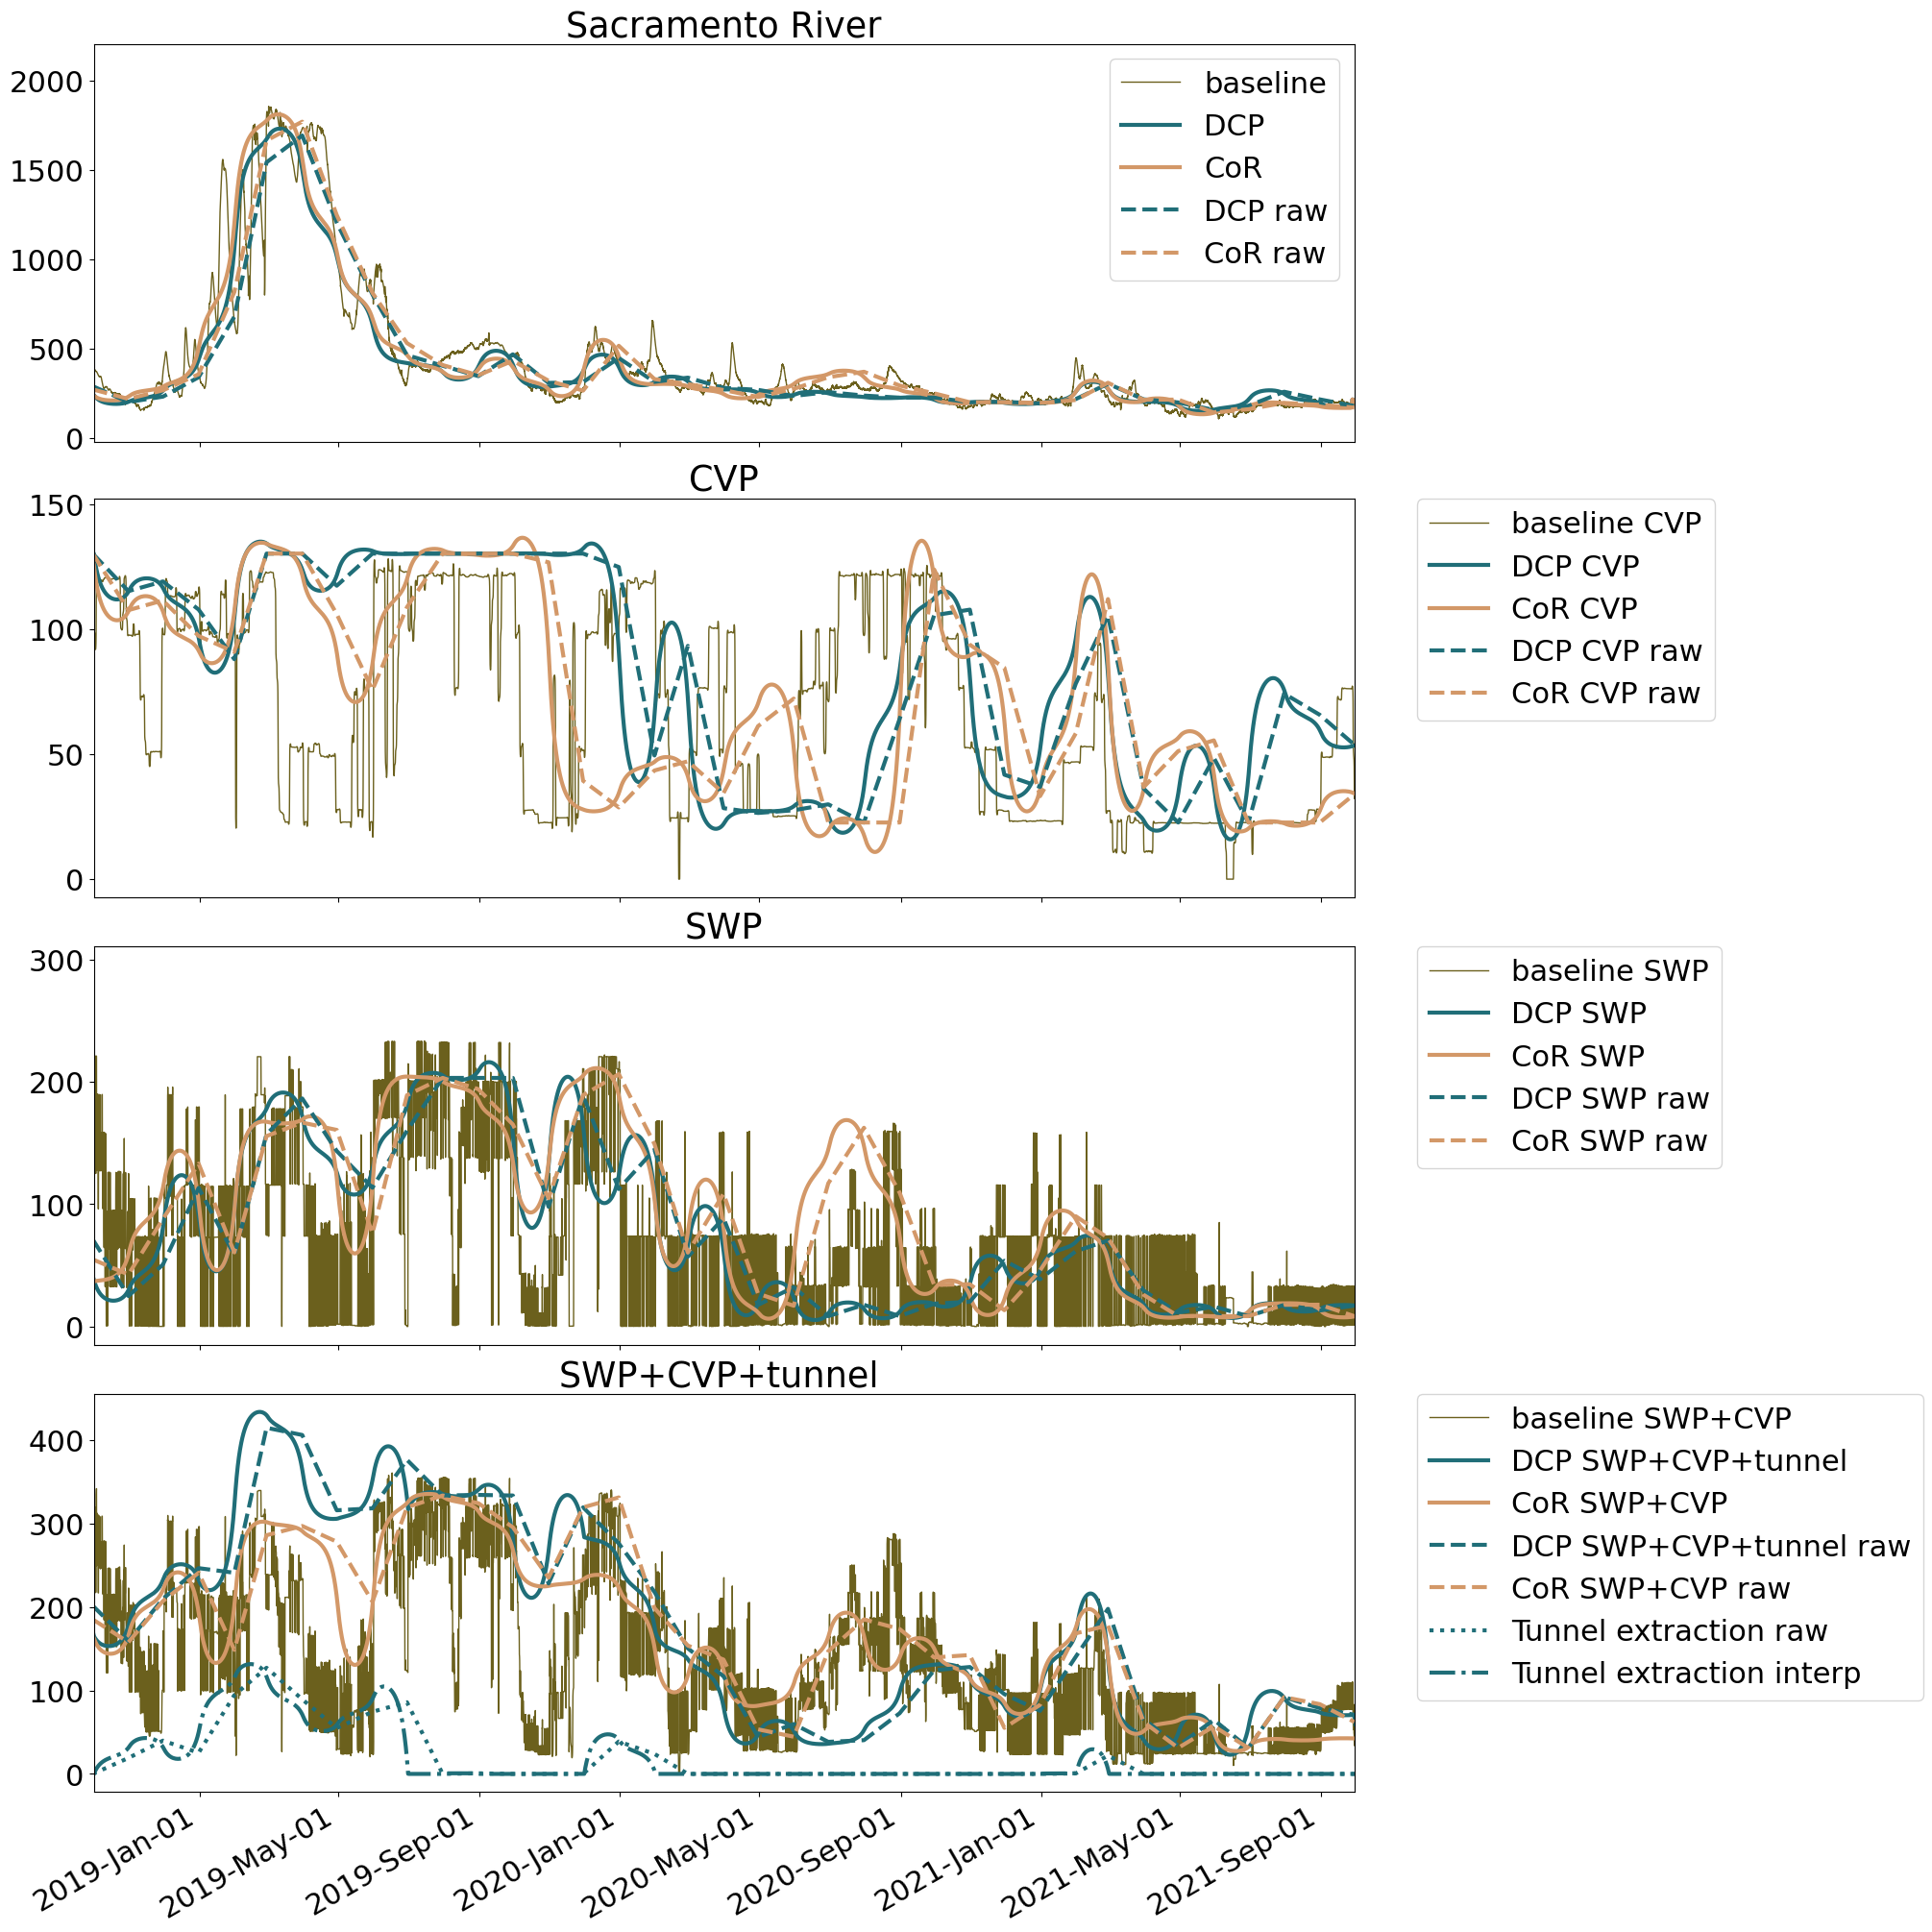

In [11]:
# make stacked plots 
fig, ax = plt.subplots(4,figsize=(20,20),sharex=True,layout='constrained')
mpl.rcParams.update({'font.size': 22})

# ax[0].plot(base.net,label='Baseline', linewidth=3,color=cmocean.cm.tarn(1/6))
# ax[0].plot(dcp.net,label='DCP', linewidth=3,color=cmocean.cm.tarn(10/12))
# ax[0].plot(cor.net,label='CoR', linewidth=3,color=cmocean.cm.tarn(2/6))
# ax[0].set_title('Inflows - Exports')
# ax[0].set_ylabel(r'Flow [$m^3 s^{-1}$]')
# ax[0].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
# ax[0].set_ylim(0,5000)
# ax[0].legend(bbox_to_anchor=(1.05, 1),
#                          loc='upper left', borderaxespad=0.)

# ax[0].plot(base.inf, linewidth=3,label='Total inflows',color=cmocean.cm.tarn(1/6))
# ax[0].plot(dcp.inf, linewidth=3,color=cmocean.cm.tarn(10/12))
# ax[0].plot(cor.inf, linewidth=3,color=cmocean.cm.tarn(2/6))

ax[0].plot(base.sac*-1, linewidth=1,color=cmocean.cm.tarn(1/6),label='baseline')#,linestyle='--')
ax[0].plot(dcp.sac*-1, linewidth=3,color=cmocean.cm.tarn(10/12),label='DCP') #,linestyle='--')
ax[0].plot(cor.sac*-1, linewidth=3,color=cmocean.cm.tarn(2/6),label='CoR')#,linestyle='--')

ax[0].plot(rawdcp.sac, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='DCP raw')
ax[0].plot(rawcor.sac, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--',label='CoR raw')
ax[0].set_title('Sacramento River')
ax[0].legend()

#ax[0].plot(cor.sac*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

# ax[1].plot(base.sjr*-1, linewidth=3,label='San Joaquin river',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.sjr*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# ax[1].plot(cor.sjr*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

# ax[1].plot(base.yolo*-1, linewidth=3,label='Yolo bypass',color=cmocean.cm.tarn(1/6),linestyle=(0,(1,1)))
# ax[1].plot(dcp.yolo*-1, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=(0,(1,1)))
# # ax[1].plot(cor.yolo*-1, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle=(0,(1,1)))

ax[1].plot(base.cvp, linewidth=1,color=cmocean.cm.tarn(1/6),label='baseline CVP')#,linestyle='--')
ax[1].plot(dcp.cvp, linewidth=3,color=cmocean.cm.tarn(10/12),label='DCP CVP') #,linestyle='--')
ax[1].plot(cor.cvp, linewidth=3,color=cmocean.cm.tarn(2/6),label='CoR CVP')#,linestyle='--')
ax[1].plot(rawdcp.C_DMC000_TD, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='DCP CVP raw')
ax[1].plot(rawcor.C_DMC000_TD, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--',label='CoR CVP raw')
ax[1].set_title('CVP')
ax[1].legend()

ax[2].plot(base.swp, linewidth=1,color=cmocean.cm.tarn(1/6),label='baseline SWP')#,linestyle='--')
ax[2].plot(dcp.swp, linewidth=3,color=cmocean.cm.tarn(10/12),label='DCP SWP') #,linestyle='--')
ax[2].plot(cor.swp, linewidth=3,color=cmocean.cm.tarn(2/6),label='CoR SWP')#,linestyle='--')
ax[2].plot(rawdcp.C_CAA003_TD, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='DCP SWP raw')
ax[2].plot(rawcor.C_CAA003_TD, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--',label='CoR SWP raw')
ax[2].set_title('SWP')
ax[2].legend()

#then plot swp+cvp AND tunnel exports 

ax[3].plot(base.swp+base.cvp, linewidth=1,color=cmocean.cm.tarn(1/6),label='baseline SWP+CVP')#,linestyle='--')
ax[3].plot(((dcp.swp+dcp.cvp).resample('D').mean()+tunnel.DCP_CMS), linewidth=3,color=cmocean.cm.tarn(10/12),label='DCP SWP+CVP+tunnel') #,linestyle='--')
ax[3].plot(cor.swp+cor.cvp, linewidth=3,color=cmocean.cm.tarn(2/6),label='CoR SWP+CVP')#,linestyle='--')
ax[3].plot(rawdcp.C_CAA003_TD+rawdcp.C_DMC000_TD+rawdcp.C_CAA003_IF, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='DCP SWP+CVP+tunnel raw')
ax[3].plot(rawcor.C_CAA003_TD+rawdcp.C_DMC000_TD, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--',label='CoR SWP+CVP raw')
ax[3].plot(rawdcp.C_CAA003_IF,linewidth=3,color=cmocean.cm.tarn(10/12),linestyle=':',label='Tunnel extraction raw')
ax[3].plot(tunnel.DCP_CMS, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='-.',label='Tunnel extraction interp')
ax[3].set_title('SWP+CVP+tunnel ')
ax[3].legend()


ax[1].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[2].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
ax[3].legend(bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)
# ax[1].set_title('Inflows')
# ax[1].set_ylabel(r'Flow [$m^3 s^{-1}$]')
# ax[1].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
# ax[1].set_ylim(0,5000)

# ax[2].plot(base.exports, linewidth=3,color=cmocean.cm.tarn(1/6))
# ax[2].plot(dcp.exports, linewidth=3,color=cmocean.cm.tarn(10/12),label='Total exports')
# ax[2].plot(cor.exports, linewidth=3,color=cmocean.cm.tarn(2/6))

# ax[2].plot(tunnel, linewidth=3,linestyle=(0,(1,1)),label='N. Delta exports',color=cmocean.cm.tarn(10/12))

# ax[2].plot(base.s_exports, linewidth=3,color=cmocean.cm.tarn(1/6),linestyle='--')
# ax[2].plot(dcp.s_exports, linewidth=3,color=cmocean.cm.tarn(10/12),linestyle='--',label='S. Delta exports')
# ax[2].plot(cor.s_exports, linewidth=3,color=cmocean.cm.tarn(2/6),linestyle='--')

ax[2].legend(bbox_to_anchor=(1.05, 1),
                          loc='upper left', borderaxespad=0.)
# ax[2].set_title('Exports')
# ax[2].set_ylabel(r'Flow [$m^3 s^{-1}$]')
ax[3].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2021-9-30"))
# ax[2].set_ylim(0,500)

ax[3].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[3].xaxis.get_major_locator()))
ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[3].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

fig.savefig('./figures/check_scenario_interpolation.png')

In [10]:
#((dcp.swp+dcp.cvp).resample('D').mean()+tunnel.DCP_CMS).plot()